<a href="https://www.kaggle.com/code/edwinagustn/validation-of-my-knowledges-intro-ml?scriptVersionId=161977745" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/melbourne-housing-market/Melbourne_housing_FULL.csv
/kaggle/input/melbourne-housing-market/MELBOURNE_HOUSE_PRICES_LESS.csv


# Descriptive Analysis

In [2]:
data = pd.read_csv('/kaggle/input/melbourne-housing-market/MELBOURNE_HOUSE_PRICES_LESS.csv')

In [3]:
data_short =  data.iloc[1:10000] # Take a subset of the data

data_short.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Postcode,Regionname,Propertycount,Distance,CouncilArea
1,Abbotsford,59A Turner St,3,h,1220000.0,S,Marshall,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
2,Abbotsford,119B Yarra St,3,h,1420000.0,S,Nelson,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
3,Aberfeldie,68 Vida St,3,h,1515000.0,S,Barry,1/04/2017,3040,Western Metropolitan,1543,7.5,Moonee Valley City Council
4,Airport West,92 Clydesdale Rd,2,h,670000.0,S,Nelson,1/04/2017,3042,Western Metropolitan,3464,10.4,Moonee Valley City Council
5,Airport West,4/32 Earl St,2,t,530000.0,S,Jellis,1/04/2017,3042,Western Metropolitan,3464,10.4,Moonee Valley City Council


**I use scatter plots to visualize correlations among some of the variables used.**

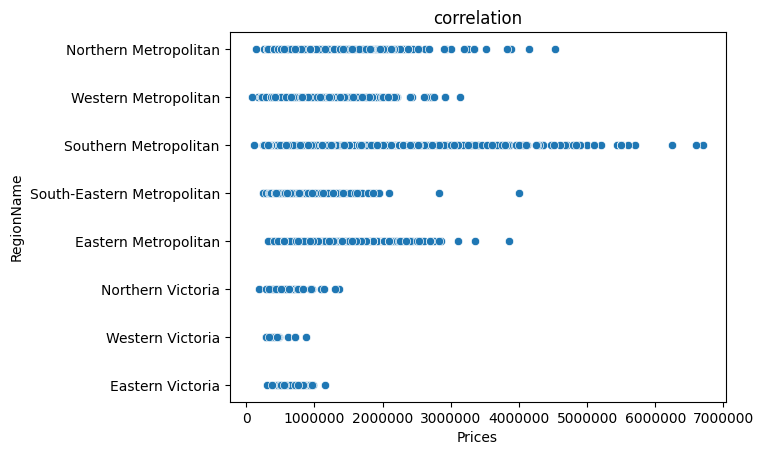

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt


#create a scatter plot with seaborn
sns.scatterplot( y=data_short['Regionname'], x=data_short['Price'],  data=data)

plt.ticklabel_format(style='plain', axis='x')

# add details with plt
plt.title('correlation')
plt.xlabel('Prices')
plt.ylabel('RegionName')


# show the plot
plt.show()


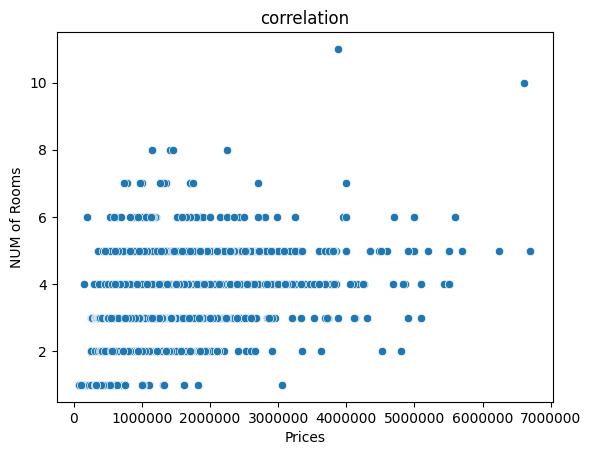

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt


#create a scatter plot with seaborn
sns.scatterplot( y=data_short['Rooms'], x=data_short['Price'],  data=data)

plt.ticklabel_format(style='plain', axis='x')

# add details with plt
plt.title('correlation')
plt.xlabel('Prices')
plt.ylabel('NUM of Rooms')


# show the plot
plt.show()

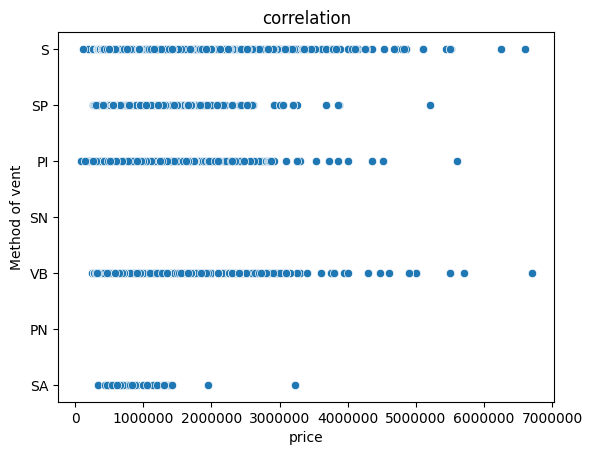

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt


#create a scatter plot with seaborn
sns.scatterplot( y=data_short['Method'], x=data_short['Price'],  data=data)

plt.ticklabel_format(style='plain', axis='x')

# add details with plt
plt.title('correlation')
plt.xlabel('price')
plt.ylabel('Method of vent')


# show the plot
plt.show()

In [7]:
# Create the features variable with categorical and numerical variables

features = data[['Rooms','Regionname', 'Address','Type','Suburb','Regionname', 'Distance', 'Propertycount', 'CouncilArea']]

features.head()


,Rooms,Regionname,Address,Type,Suburb,Regionname,Distance,Propertycount,CouncilArea
0,3,Northern Metropolitan,49 Lithgow St,h,Abbotsford,Northern Metropolitan,3.0,4019,Yarra City Council
1,3,Northern Metropolitan,59A Turner St,h,Abbotsford,Northern Metropolitan,3.0,4019,Yarra City Council
2,3,Northern Metropolitan,119B Yarra St,h,Abbotsford,Northern Metropolitan,3.0,4019,Yarra City Council
3,3,Western Metropolitan,68 Vida St,h,Aberfeldie,Western Metropolitan,7.5,1543,Moonee Valley City Council
4,2,Western Metropolitan,92 Clydesdale Rd,h,Airport West,Western Metropolitan,10.4,3464,Moonee Valley City Council


In [8]:
from sklearn.preprocessing import OrdinalEncoder # Transform categorical data into numerical data

Encoder = OrdinalEncoder() # Initialize the OrdinalEncoder function

names_cat =  features.select_dtypes(include='object').columns #names of columns

# Fit and transform the columns using OrdinalEncoder
features[names_cat] = Encoder.fit_transform(features[names_cat])  
features


/tmp/ipykernel_18/4099579486.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[names_cat] = Encoder.fit_transform(features[names_cat])


,Rooms,Regionname,Address,Type,Suburb,Regionname,Distance,Propertycount,CouncilArea
0,3,2.0,42390.0,0.0,0.0,2.0,3.0,4019,32.0
1,3,2.0,46855.0,0.0,0.0,2.0,3.0,4019,32.0
2,3,2.0,8180.0,0.0,0.0,2.0,3.0,4019,32.0
3,3,6.0,50133.0,0.0,1.0,6.0,7.5,1543,22.0
4,2,6.0,57182.0,0.0,2.0,6.0,10.4,3464,22.0
...,...,...,...,...,...,...,...,...,...
63018,3,2.0,29496.0,0.0,295.0,2.0,20.6,5833,11.0
63019,3,2.0,56375.0,0.0,295.0,2.0,20.6,5833,11.0
63020,3,2.0,43497.0,0.0,295.0,2.0,20.6,5833,11.0
63021,3,2.0,30605.0,2.0,332.0,2.0,15.3,7955,30.0


# Model Creation

In [9]:
# Fill missing values in the target variable with the mean price 
y = data['Price']
y =  y.fillna(y.mean())

X = features # Assign features to variable X 


In [10]:
from sklearn.tree import DecisionTreeRegressor 


regressor = DecisionTreeRegressor(random_state = 1)
regressor.fit(X,y) # Fit the model 

DecisionTreeRegressor(random_state=1)

In [11]:
 predict = regressor.predict(features)  # Predict house prices

# Model Validation

In [12]:
from sklearn.metrics import mean_absolute_error # Method for validating the model


mean_absolute_error(y, predict) # Calculate the Mean Absolute Error (MAE) between the target and predictions

3420.6151685798764